In [1]:
from utilities import * 
from myCGAN import MyCGAN
from myCWGAN import MyCWGAN
import pandas as pd
import numpy as np


# DATA MANAGEMENT

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 3        # Number of time steps
J = 2        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

sim.get_paths()
sim.get_pdf(n_steps_ahead=10, n_bins=3)
sim.save_binary_file('data/inputs/demo')
print(sim.paths)
print(sim.pdf)

In [ ]:
file_paths, file_pdf = sim.load_binary_file('data/inputs/demo.bin')

In [ ]:
print(file_paths)
print(file_pdf)

# MEAN AND VARIANCE

In [2]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10)

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='standardization')


conditional_gan = MyCGAN(max_epoch= 100, name = 'CGAN_mean_std')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1])
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='mean_std_error_dist.csv')


In [ ]:
plot_learning_curve('generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/mean_std_error_dist.csv')
print(means,'\n', std, '\n', summary)

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100, verbose=True)
pdfs

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100)
pdfs

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='log')


conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_p')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='bins_p_error_dist.csv')


In [ ]:
plot_learning_curve('generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/bins_p_error_dist.csv')
print(means,'\n', std, '\n', summary)

In [ ]:
summary

## ks test 

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100        # Number of paths to simulate
SEED=1

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = val.get_paths()
pdfs= val.get_pdf(n_steps_ahead=10, n_bins=100)
bins = val.bins

In [ ]:
conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_p')
conditional_gan.load_models()

In [4]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
preds, _ = conditional_gan.generate(mydata)

generated = np.exp(preds)


In [ ]:
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_df

In [ ]:
generated_sample = generated[0]
true_sample = pdfs[0]

plot_bin_dist(true_sample, generated_sample, bins)



# CGAN BINS PROBABILITIES 


In [ ]:
# data simulation 
# example
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=1, n_bins=100)
sim.save_configuration('./models/bins/CGAN_100b.json')
pdfs

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='log')

generator_params = {"hidden_dims": [512, 256, 256, 128]}
discriminator_params = {"hidden_dims": [512, 256, 256, 128, 64]}
conditional_gan = MyCGAN(max_epoch=100, name='CGAN_100b')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True, **generator_params)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1], output_dim=1, **discriminator_params)
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='cgan_100b_errors.csv')


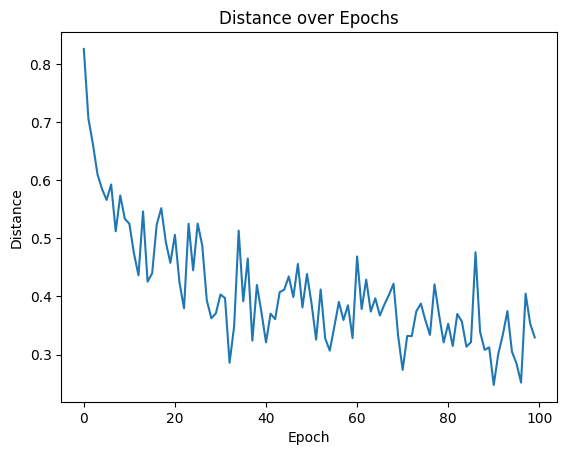

In [4]:
plot_learning_curve('generated_vs_true.csv')

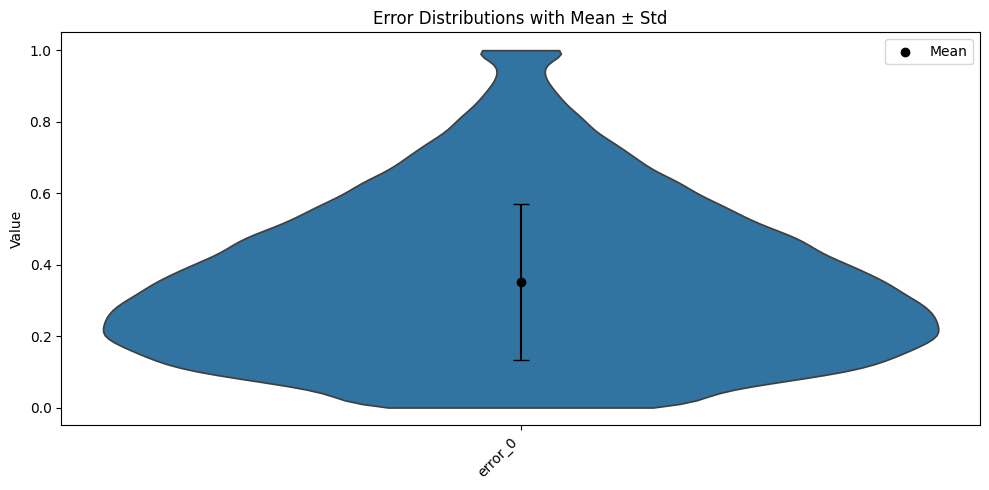

error_0    0.35127
dtype: float64 
 error_0    0.218632
dtype: float64 
             mean       std    median      skew  kurtosis  is_zero_test  \
error_0  0.35127  0.218632  0.318176  0.655748 -0.044113         False   

                               confidence_interval  
error_0  (0.34991502465302754, 0.3526252059783325)  


In [6]:
means, std, summary = analyze_error_distribution('./data/results/cgan_100b_errors.csv')
print(means,'\n', std, '\n', summary)

## KS TEST

In [22]:
# data simulation 
# example

X0_range = (0.0, 0.0)#[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = (0.0, 0.0)#[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = (0.05, 0.6)#[0.001, 0.01, 0.05, 0.1, 0.5, 0.8]
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CGAN_100b.json')
paths = val.get_paths()
pdfs = val.get_pdf(n_steps_ahead=1)
Xt = val.X_T
bins = val.bins

conditional_gan = MyCGAN(max_epoch=100, name='CGAN_100b')
conditional_gan.load_models()


Bins loaded from models\bins\CGAN_100b.json
Loaded 101 bins
CGAN config loaded from ./models\CGAN_100b_config.json
Generator loaded from ./models\CGAN_100b_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 252, 'condition_size': 253, 'output_dim': 100, 'hidden_dims': [512, 256, 256, 128], 'is_prob': True, 'use_batch_norm': True, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\CGAN_100b_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 100, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}


In [ ]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
_, preds = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.05]
print(len(test_h0)/len(test_df))

error_metrics = get_error_metrics(pdfs, generated)
for metric_name, metric in error_metrics.items():
    print(f'the {metric_name} is: {np.mean(metric)}\n')


0.298


,p_values
1,0.849433
2,0.959366
4,0.163074
5,0.261501
6,1.000000
...,...
991,0.066181
993,0.147062
994,0.643444
997,1.000000


In [26]:
error_metrics = get_error_metrics(pdfs, generated)
for metric_name, metric in error_metrics.items():
    print(f'the {metric_name} is: {np.mean(metric)}\n')

the mae is: 0.006156041692067987

the js_distance is: 0.3430049362091364

the hellinger_distance is: 0.3067204701582432

the tv_distance is: 0.3078020846033994



In [19]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.03, 0.07, 0.1, 0.3, 0.5, 0.7]
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CGAN_100b.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
pdfs = val.get_pdf(n_steps_ahead=1, P=paths[:, -1])
Xt = val.X_T
bins = val.bins


conditional_gan = MyCGAN(max_epoch=100, name='CGAN_100b')
conditional_gan.load_models()



mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
_, preds = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.05]
print(len(test_h0)/len(test_df))
test_h0


Bins loaded from models\bins\CGAN_100b.json
Loaded 101 bins
CGAN config loaded from ./models\CGAN_100b_config.json
Generator loaded from ./models\CGAN_100b_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 252, 'condition_size': 253, 'output_dim': 100, 'hidden_dims': [512, 256, 256, 128], 'is_prob': True, 'use_batch_norm': True, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\CGAN_100b_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 100, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
0.3333333333333333


,p_values
2,1.000000
3,0.999991


In [20]:
js_divergence = compute_js(generated, pdfs, is_log=False)
mean_js = np.mean(js_divergence)
print(f'js_divergence for each sample is {js_divergence}. The mean divergence is {mean_js}')

js_divergence for each sample is [np.float64(0.5189563647613251), np.float64(0.53662516147538), np.float64(0.05496966365717054), np.float64(0.12063693390921344), np.float64(0.6691442188344264), np.float64(0.6134917645278953)]. The mean divergence is 0.41897068452756847


In [ ]:
Xt

In [ ]:
#generated_sample = generated[-1]
#true_sample = pdfs[-1]
#plot_bin_dist(true_sample, generated_sample, bins, Xt[-1])

plot_bin_dist(pdfs, generated, bins, Xt, ncols=3)



# CWGAN BINS PROBABILITIES

In [ ]:
# data simulation 
# example
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=1, n_bins=100)
sim.save_configuration('./models/bins/CWGAN_v0.json')
pdfs

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess="log")

generator_params = {"hidden_dims": [512, 256, 256, 128], "use_batch_norm":False}
critic_params = {"hidden_dims": [512, 256, 256, 128, 64], 'use_layer_norm':True}
conditional_gan = MyCWGAN(max_epoch=100, name='CWGAN_v0')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True, **generator_params)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=True, early_stopping_waiting=100)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='CWGAN_error_v0.csv')


In [ ]:
plot_learning_curve('wcgan_generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/CWGAN_v0.csv')
print(means,'\n', std, '\n', summary)

## KS TEST

In [27]:
# data simulation 
# example

X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.05, 0.6)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CWGAN_v0.json')
paths = val.get_paths()
pdfs = val.get_pdf(n_steps_ahead=1)
Xt = val.X_T
bins = val.bins

conditional_gan = MyCGAN(max_epoch=100, name='CWGAN_v0')
conditional_gan.load_models()



Bins loaded from models\bins\CWGAN_v0.json
Loaded 101 bins
CGAN config loaded from ./models\CWGAN_v0_config.json
Generator loaded from ./models\CWGAN_v0_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 252, 'condition_size': 253, 'output_dim': 100, 'hidden_dims': [512, 256, 256, 128], 'is_prob': True, 'use_batch_norm': False, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\CWGAN_v0_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 100, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}


In [28]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
_, preds = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print(len(test_h0)/len(test_df))
test_h0


0.412


,p_values
0,0.197153
1,0.999998
3,1.000000
5,0.095525
6,1.000000
...,...
989,0.417486
994,0.764545
995,0.466718
997,1.000000


In [30]:
error_metrics = get_error_metrics(pdfs, generated)
for metric_name, metric in error_metrics.items():
    print(f'the {metric_name} is: {np.mean(metric)}\n')

the mae is: 0.00545012549837964

the js_distance is: 0.3050277923835073

the hellinger_distance is: 0.2711517301244348

the tv_distance is: 0.27250627491898194



In [ ]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.03, 0.07, 0.1, 0.3, 0.5, 0.7]
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CWGAN_v0.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
pdfs = val.get_pdf(n_steps_ahead=1, P=paths[:, -1])
Xt = val.X_T
bins = val.bins


conditional_gan = MyCGAN(max_epoch=100, name='CWGAN_v0')
conditional_gan.load_models()


Bins loaded from models\bins\CWGAN_v0.json
Loaded 101 bins
CGAN config loaded from ./models\CWGAN_v0_config.json
Generator loaded from ./models\CWGAN_v0_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 252, 'condition_size': 253, 'output_dim': 100, 'hidden_dims': [512, 256, 256, 128], 'is_prob': True, 'use_batch_norm': False, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\CWGAN_v0_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 100, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}


In [10]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
_, preds = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print(len(test_h0)/len(test_df))
test_h0


0.5


,p_values
0,1.000000
1,0.514957
2,1.000000


In [11]:
js_divergence = compute_js(generated, pdfs, is_log=False)
mean_js = np.mean(js_divergence)
print(f'js_divergence for each sample is {js_divergence}. The mean divergence is {mean_js}')

js_divergence for each sample is [np.float64(0.00018151219131523163), np.float64(0.14383606839277413), np.float64(0.03836084454393223), np.float64(0.24365957523197834), np.float64(0.9241381303515491), np.float64(0.23197149922807714)]. The mean divergence is 0.2636912716566044


In [ ]:
Xt

In [ ]:
#generated_sample = generated[-1]
#true_sample = pdfs[-1]
#plot_bin_dist(true_sample, generated_sample, bins, Xt[-1])

plot_bin_dist(pdfs, generated, bins, Xt, ncols=3)



# FORGAN simple

In [44]:
# to train a forgan we simulate the J trajectories and the target output is given by the 1-step ahead value
# so just the path are generated and the last values of each trajectory is used as target 
# at inference time the pdf is the one at 1 day ahead
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=100, P=paths[:, -1], n_steps_ahead=1)
sim.save_configuration('./models/bins/forgan_simple.json')

Bins saved to models\bins\forgan_simple.json


In [ ]:
mydata, _, _ = prepare_data(targets, paths)

generator_params = {"hidden_dims": [512, 256, 128, 64], "use_batch_norm":True}
critic_params = {"hidden_dims": [512, 256, 256, 128, 64], 'use_layer_norm':False}
conditional_gan = MyCGAN(max_epoch=100, name='forgan_simple', z_noise_dim=64)
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=targets.shape[1], **generator_params)
conditional_gan.set_discriminator(input_size=targets.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=True, distance_metric='mse')
conditional_gan.save_models() 
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='forgan_simple.csv')


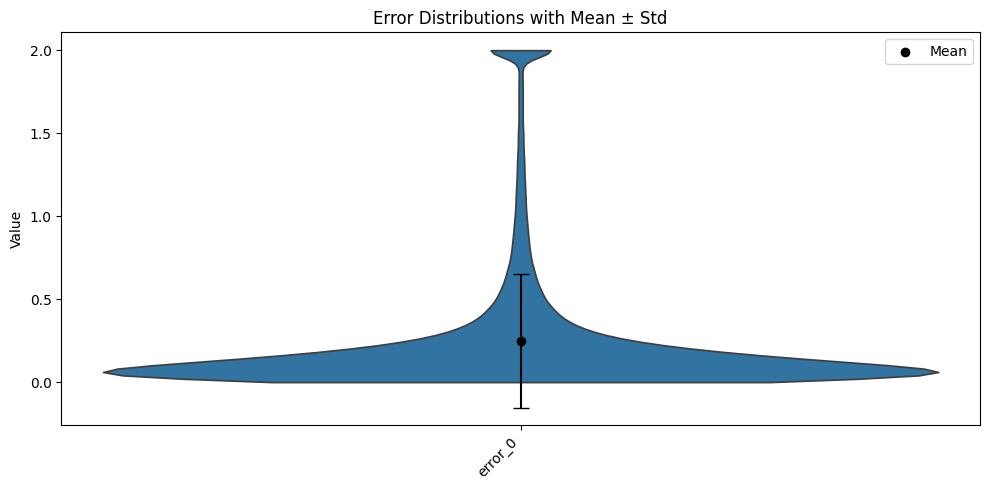

error_0    0.247726
dtype: float64 
 error_0    0.401025
dtype: float64 
              mean       std    median      skew   kurtosis  is_zero_test  \
error_0  0.247726  0.401025  0.112539  3.155226  10.000242         False   

                                confidence_interval  
error_0  (0.24523996364248796, 0.25021109187599544)  


In [3]:
means, std, summary = analyze_error_distribution('./data/results/forgan_simple.csv')
print(means,'\n', std, '\n', summary)

## ks test

In [2]:
# data simulation 
# example

X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.05, 0.6)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)

# model 
conditional_gan = MyCGAN(max_epoch=100, name='forgan_simple')
conditional_gan.load_models()


mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = None)
true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(pdfs, generated)

p_values = []
for i, row in enumerate(true_pdfs):
    _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print("percentage of acceptance of KS test: ", len(test_h0)/len(test_df))

stats = get_error_metrics(true=true_pdfs, generated=generated_pdfs)
for key, metric in stats.items():
    print(key, np.mean(metric))




CGAN config loaded from ./models\forgan_simple_config.json
Generator loaded from ./models\forgan_simple_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 64, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 128, 64], 'is_prob': False, 'use_batch_norm': True, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_simple_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (1000, 1000)
percentage of acceptance of KS test:  0.2725450901803607
js_distance 0.5730828547985307
hellinger_distance 0.5301088773965936
tv_distance 0.5529258460991782
emd_distance 0.027409322263530767


In [4]:
# data simulation 
# example

X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.05, 0.6)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/forgan_simple.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = val.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)

conditional_gan = MyCGAN(max_epoch=100, name='forgan_simple')
conditional_gan.load_models()



mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = None)



true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(pdfs, generated)

p_values = []
for i, row in enumerate(true_pdfs):
    _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print("percentage of acceptance of KS test: ", len(test_h0)/len(test_df))

stats = get_error_metrics(true=true_pdfs, generated=generated_pdfs)
for key, metric in stats.items():
    print(key, np.mean(metric))


Bins loaded from models\bins\forgan_simple.json
Loaded 101 bins
CGAN config loaded from ./models\forgan_simple_config.json
Generator loaded from ./models\forgan_simple_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 64, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 128, 64], 'is_prob': False, 'use_batch_norm': True, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_simple_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (1000, 1000)
percentage of acceptance of KS test:  0.273


c:\Users\matte\LEARNING\MAGISTRALE\QUANTITATIVE FINANCE\TESI\cGAN_code\utilities.py:132: RuntimeWarning: invalid value encountered in divide
  generated_discretized_pdfs.append(hist_generated/hist_generated.sum())


js_distance nan
hellinger_distance nan
tv_distance nan
emd_distance nan


In [6]:
filepath = "models/forgan_simple_discriminator.pth"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(filepath, map_location=device)
state_dict = checkpoint['model_state_dict']
# Remap 'layer.' to 'layers.' in keys
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('layer.'):
        new_k = k.replace('layer.', 'layers.')
    else:
        new_k = k
    new_state_dict[new_k] = v
checkpoint['model_state_dict'] = new_state_dict
torch.save(checkpoint, filepath)

In [3]:
# data simulation 
# example


X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.03, 0.07, 0.1, 0.3, 0.5, 0.7]
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/forgan_simple.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = val.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)

conditional_gan = MyCGAN(max_epoch=100, name='forgan_simple')
conditional_gan.load_models()



mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = None)



true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(pdfs, generated)

p_values = []
for i, row in enumerate(true_pdfs):
    _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print("percentage of acceptance of KS test: ", len(test_h0)/len(test_df))

stats = get_error_metrics(true=true_pdfs, generated=generated_pdfs)
for key, metric in stats.items():
    print(key, np.mean(metric))

Bins loaded from models\bins\forgan_simple.json
Loaded 101 bins
CGAN config loaded from ./models\forgan_simple_config.json
Generator loaded from ./models\forgan_simple_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 64, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 128, 64], 'is_prob': False, 'use_batch_norm': True, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_simple_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (6, 1000)
percentage of acceptance of KS test:  0.16666666666666666
js_distance 0.6389803718953667
hellinger_distance 0.5996931351377973
tv_distance 0.6204337645019741
emd_distance 0.027803893649224014


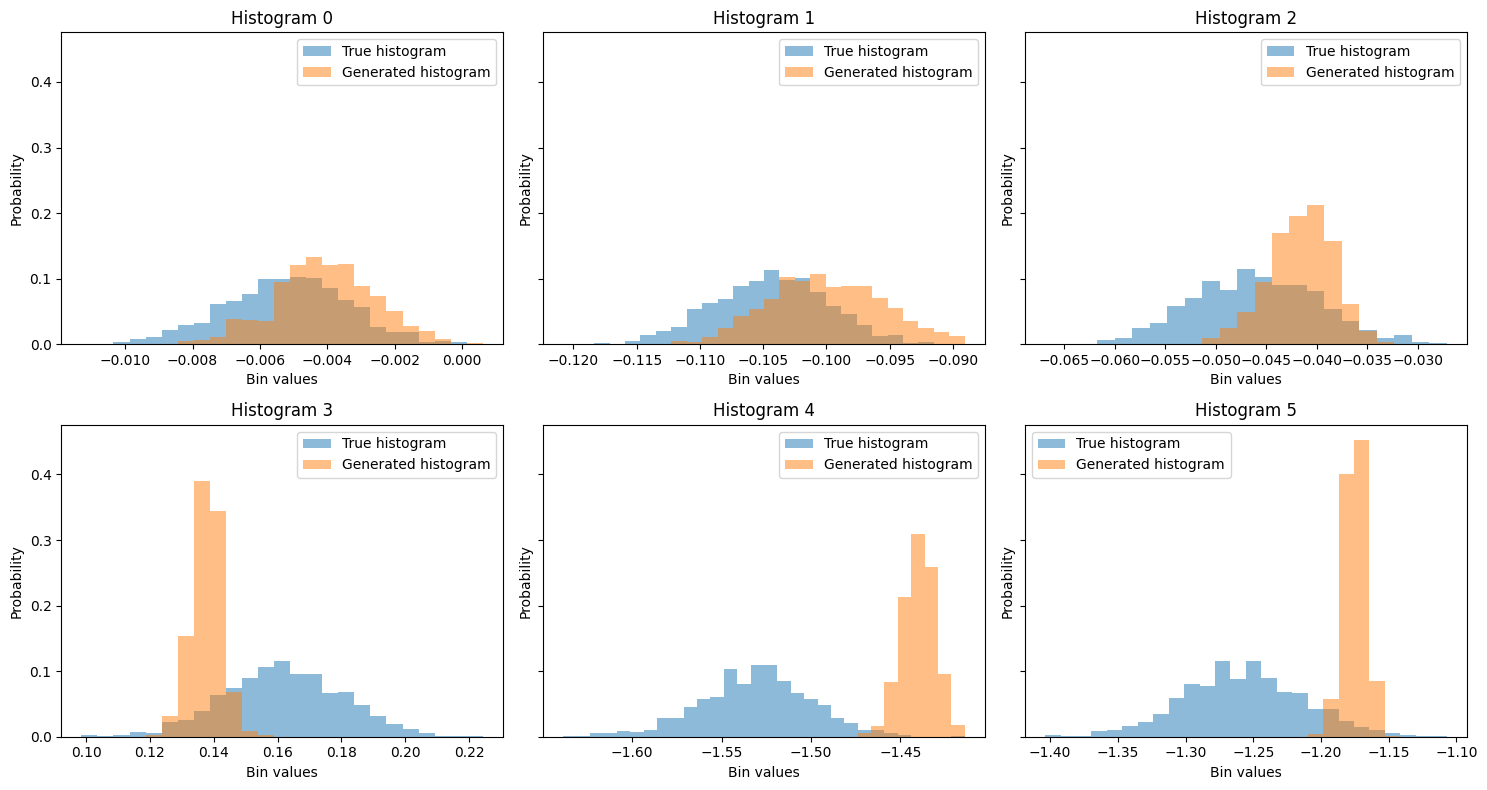

In [5]:
plot_bin_dist(true_pdfs, generated_pdfs, bins_values=bin_edges_list)


# FORGAN

In [ ]:
# to train a forgan we simulate the J trajectories and the target output is given by the 1-step ahead value
# so just the path are generated and the last values of each trajectory is used as target 
# at inference time the pdf is the one at 1 day ahead
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=100, P=paths[:, -1], n_steps_ahead=1)
sim.save_configuration('./models/bins/forgan_v3.json')

Bins saved to models\bins\forgan_v3.json


In [ ]:
mydata, _, _ = prepare_data(targets, paths)

generator_params = {"hidden_dims": [512, 256, 128, 64], "use_batch_norm":False}
critic_params = {"hidden_dims": [512, 256, 256, 128, 64], 'use_layer_norm':True}
conditional_gan = MyCWGAN(max_epoch=100, name='forgan_v3', z_noise_dim=64)
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=targets.shape[1], **generator_params)
conditional_gan.set_discriminator(input_size=targets.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=True, early_stopping_waiting=100, distance_metric='mse')
conditional_gan.save_models() 
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='forgan_v3.csv')


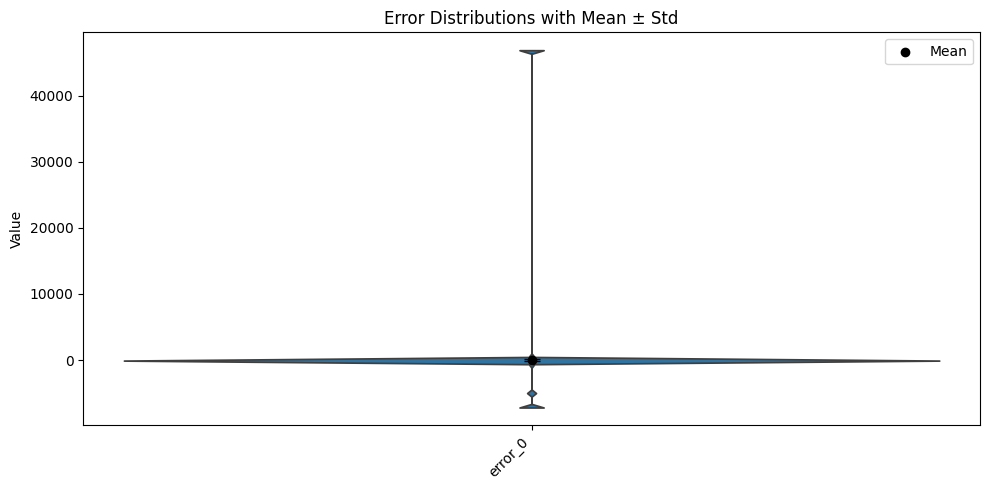

error_0    0.33918
dtype: float64 
 error_0    153.497078
dtype: float64 
             mean         std    median        skew      kurtosis  \
error_0  0.33918  153.497078 -0.026294  284.653331  86965.459361   

         is_zero_test                        confidence_interval  
error_0          True  (-0.6121983947104437, 1.2905591652713824)  


In [10]:
means, std, summary = analyze_error_distribution('./data/results/forgan_v3.csv')
print(means,'\n', std, '\n', summary)

## KS test 

In [3]:
# data simulation 
# example

X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.05, 0.6)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

sim.load_configuration('./models/bins/forgan_v3.json')
trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)

# model 
conditional_gan = MyCWGAN(max_epoch=100, name='forgan_v3')
conditional_gan.load_models()


mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = None)

true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(pdfs, generated)

p_values = []
for i, row in enumerate(true_pdfs):
    _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print("percentage of acceptance of KS test: ", len(test_h0)/len(test_df))

stats = get_error_metrics(true=true_pdfs, generated=generated_pdfs)
for key, metric in stats.items():
    print(key, np.mean(metric))




Bins loaded from models\bins\forgan_v3.json
Loaded 101 bins
CGAN config loaded from ./models\forgan_v3_config.json
Generator loaded from ./models\forgan_v3_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 64, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 128, 64], 'is_prob': False, 'use_batch_norm': False, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_v3_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (1000, 1000)
percentage of acceptance of KS test:  0.556
js_distance 0.38706390705611093
hellinger_distance 0.3441411742552233
tv_distance 0.3588618783792065
emd_distance 0.01458814577409015


### visual

In [6]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.03, 0.07, 0.1, 0.3, 0.5, 0.7]
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)

# model 
conditional_gan = MyCWGAN(max_epoch=100, name='forgan_v3')
conditional_gan.load_models()


mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = None)

true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(pdfs, generated)

p_values = []
for i, row in enumerate(true_pdfs):
    _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print("percentage of acceptance of KS test: ", len(test_h0)/len(test_df))

stats = get_error_metrics(true=true_pdfs, generated=generated_pdfs)
for key, metric in stats.items():
    print(key, np.mean(metric))


CGAN config loaded from ./models\forgan_v3_config.json
Generator loaded from ./models\forgan_v3_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 64, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 128, 64], 'is_prob': False, 'use_batch_norm': False, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_v3_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (6, 1000)
percentage of acceptance of KS test:  0.8333333333333334
js_distance 0.380222721797382
hellinger_distance 0.3380865661986996
tv_distance 0.34390379554941664
emd_distance 0.018080063454211922


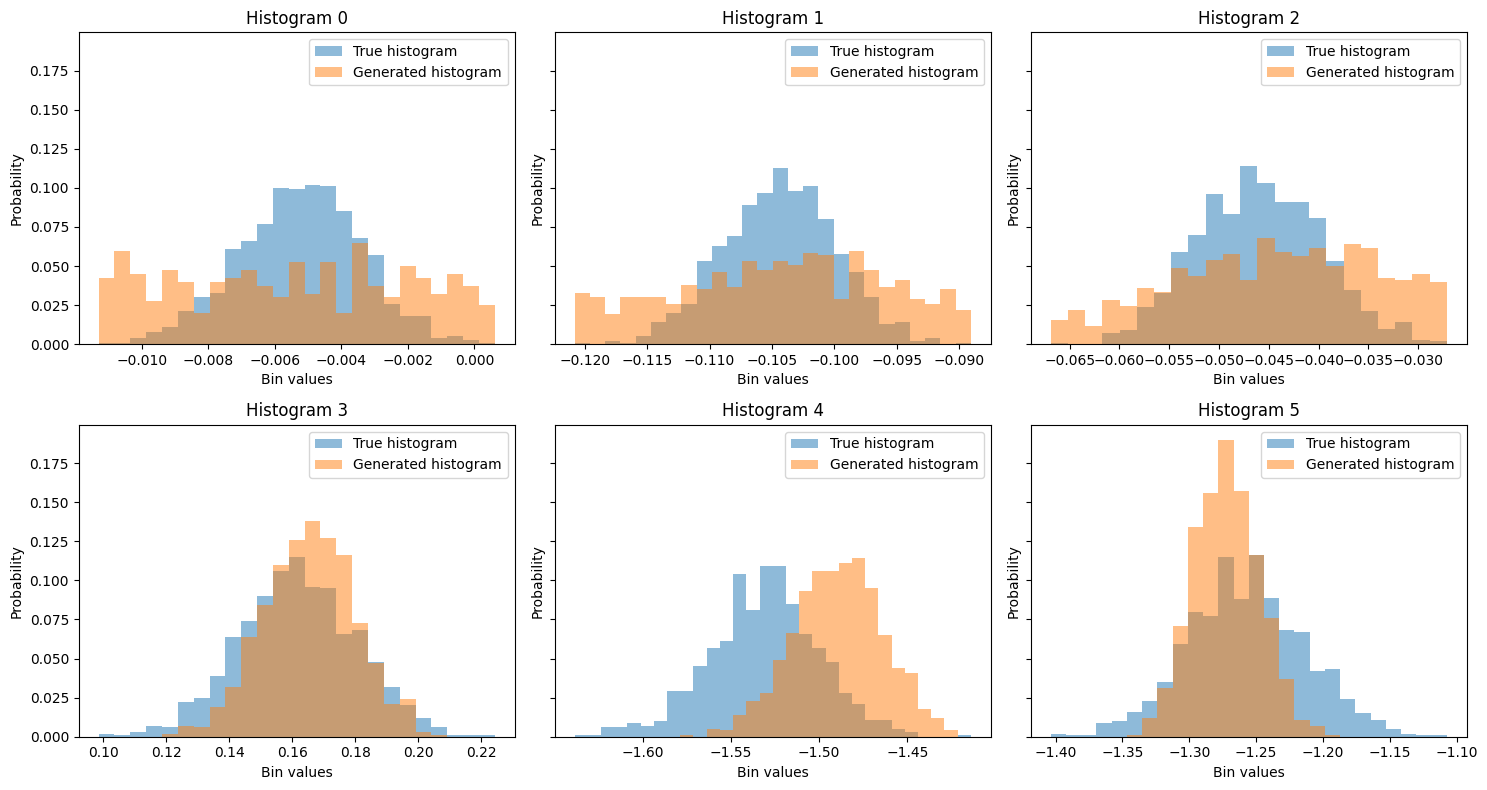

In [7]:
plot_bin_dist(true_pdfs, generated_pdfs, bins_values=bin_edges_list)

# FORWGAN 2 params

In [2]:
# to train a forgan we simulate the J trajectories and the target output is given by the 1-step ahead value
# so just the path are generated and the last values of each trajectory is used as target 
# at inference time the pdf is the one at 1 day ahead
X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.5, 0.5)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths(get_proxy_n=2)
trajectories


array([[ 0.5       , -0.30228534, -0.31041222],
       [ 0.5       ,  0.32629368,  0.29052855],
       [ 0.5       , -0.28817646, -0.27540564],
       ...,
       [ 0.5       ,  1.16569064,  1.1777627 ],
       [ 0.5       , -0.93899815, -0.89581205],
       [ 0.5       , -0.07348507, -0.12749879]], shape=(100000, 3))

In [ ]:
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
#pdfs = sim.get_pdf(n_bins=100, P=paths[:, -1], n_steps_ahead=1)
sim.save_configuration('./models/bins/forgan_debug.json')


Bins saved to models\bins\forgan_debug.json


array([], shape=(6, 0), dtype=float32)

In [ ]:
mydata, _, _ = prepare_data(targets, paths)

generator_params = {"hidden_dims": [32, 64, 32], "use_batch_norm":False}
critic_params = {"hidden_dims": [32, 64, 64, 32], 'use_layer_norm':True}
conditional_gan = MyCWGAN(max_epoch=100, name='forgan_debug', z_noise_dim=32)
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=targets.shape[1], **generator_params)
conditional_gan.set_discriminator(input_size=targets.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=False, early_stopping_waiting=100, distance_metric='mse')
conditional_gan.save_models() 
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='forgan_debug.csv')


Epoch: 0/100, Step: 0, C_loss: 2.9624, G_loss: -0.5471, W_dist: -0.0383, GP: 0.2924
Epoch: 0/100, Step: 500, C_loss: 1.6032, G_loss: -0.4461, W_dist: -0.9264, GP: 0.0677
Epoch: 0/100, Step: 1000, C_loss: 7.4285, G_loss: -1.3056, W_dist: -2.2477, GP: 0.5181
Epoch: 0/100, Step: 1500, C_loss: -3.5846, G_loss: 0.9209, W_dist: 3.9657, GP: 0.0381
Epoch: 0/100, Step: 2000, C_loss: -0.2728, G_loss: -1.7376, W_dist: 0.3124, GP: 0.0040
Epoch: 0/100, Step: 2500, C_loss: 1.4803, G_loss: -2.6323, W_dist: -1.2158, GP: 0.0265
Epoch: 0/100, Step: 3000, C_loss: 5.5721, G_loss: -1.8583, W_dist: -2.8234, GP: 0.2749
Epoch: 1/100, Step: 3500, C_loss: 9.6379, G_loss: -0.7354, W_dist: -2.1350, GP: 0.7503
Epoch: 1/100, Step: 4000, C_loss: 9.6205, G_loss: -0.8467, W_dist: -2.0926, GP: 0.7528
Epoch: 1/100, Step: 4500, C_loss: -5.9409, G_loss: 3.6049, W_dist: 7.3037, GP: 0.1363
Epoch: 1/100, Step: 5000, C_loss: -0.5899, G_loss: -2.9085, W_dist: 0.6853, GP: 0.0095
Epoch: 1/100, Step: 5500, C_loss: 1.8007, G_loss:

In [2]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths(get_proxy_n=2)
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)

# model 
conditional_gan = MyCWGAN(max_epoch=100, name='forgan_debug')
conditional_gan.load_models()


mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = None)

true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(pdfs, generated)

p_values = []
for i, row in enumerate(true_pdfs):
    _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print("percentage of acceptance of KS test: ", len(test_h0)/len(test_df))

stats = get_error_metrics(true=true_pdfs, generated=generated_pdfs)
for key, metric in stats.items():
    print(key, np.mean(metric))


CGAN config loaded from ./models\forgan_debug_config.json
Generator loaded from ./models\forgan_debug_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 32, 'condition_size': 2, 'output_dim': 1, 'hidden_dims': [64, 128, 64, 32], 'is_prob': False, 'use_batch_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_debug_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 2, 'output_dim': 1, 'hidden_dims': [64, 128, 128, 64, 32], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (6, 1000)
percentage of acceptance of KS test:  0.8333333333333334
js_distance 0.5112181099088554
hellinger_distance 0.4622905313156438
tv_distance 0.46598528753599117
emd_distance 0.011900341651536936


In [12]:
for el in mydata:
    print(el)

(tensor([-0.2412]), tensor([ 0.5000, -0.2036]))
(tensor([-0.8693]), tensor([ 0.5000, -0.8545]))
(tensor([-0.3389]), tensor([ 0.5000, -0.3296]))
(tensor([0.2190]), tensor([0.5000, 0.2182]))
(tensor([-1.4990]), tensor([ 0.5000, -1.5313]))
(tensor([-0.8413]), tensor([ 0.5000, -0.8493]))


In [20]:
for el in generated:
    print(np.min(el), np.max(el), np.mean(el))


-3.1183312 2.7286062 0.0045433263
-3.5324223 3.264167 -0.03597754
-3.185239 3.277563 0.00046743202
-3.159346 2.656712 -0.01939948
-3.173104 3.0867896 -0.0021301794
-3.2170727 3.1379766 -0.030309249


In [5]:
for el in true_pdfs:
    print(el)

[0.001 0.001 0.002 0.002 0.007 0.009 0.012 0.018 0.025 0.025 0.045 0.045
 0.053 0.06  0.076 0.081 0.085 0.07  0.081 0.072 0.064 0.051 0.039 0.023
 0.017 0.012 0.012 0.003 0.005 0.    0.003 0.001]
[0.001 0.    0.001 0.001 0.001 0.003 0.012 0.012 0.02  0.022 0.047 0.051
 0.056 0.056 0.083 0.074 0.093 0.079 0.085 0.08  0.062 0.05  0.04  0.024
 0.017 0.013 0.01  0.002 0.002 0.002 0.    0.001]
[0.001 0.    0.    0.    0.003 0.008 0.005 0.016 0.019 0.037 0.038 0.048
 0.056 0.072 0.061 0.069 0.09  0.072 0.061 0.065 0.075 0.054 0.044 0.031
 0.022 0.022 0.006 0.009 0.009 0.004 0.001 0.002]
[0.001 0.001 0.002 0.002 0.007 0.003 0.016 0.015 0.02  0.028 0.042 0.053
 0.066 0.069 0.089 0.084 0.082 0.077 0.067 0.062 0.057 0.045 0.038 0.025
 0.019 0.012 0.009 0.006 0.001 0.    0.001 0.001]
[0.001 0.001 0.005 0.004 0.008 0.007 0.007 0.02  0.029 0.037 0.041 0.054
 0.068 0.092 0.077 0.104 0.103 0.078 0.069 0.059 0.042 0.032 0.025 0.01
 0.011 0.01  0.003 0.002 0.    0.    0.    0.001]
[0.001 0.001 0.001 0.

In [4]:
generated_pdfs

[array([0.0212766 , 0.03191489, 0.0212766 , 0.0106383 , 0.04255319,
        0.0106383 , 0.0212766 , 0.03191489, 0.05319149, 0.03191489,
        0.0212766 , 0.05319149, 0.0212766 , 0.0106383 , 0.04255319,
        0.03191489, 0.04255319, 0.03191489, 0.0212766 , 0.04255319,
        0.03191489, 0.0212766 , 0.05319149, 0.05319149, 0.0106383 ,
        0.03191489, 0.06382979, 0.0212766 , 0.0106383 , 0.03191489,
        0.03191489, 0.04255319]),
 array([0.02941176, 0.        , 0.02941176, 0.02941176, 0.02941176,
        0.04411765, 0.01470588, 0.        , 0.01470588, 0.02941176,
        0.02941176, 0.01470588, 0.01470588, 0.02941176, 0.04411765,
        0.08823529, 0.02941176, 0.04411765, 0.01470588, 0.04411765,
        0.04411765, 0.05882353, 0.05882353, 0.02941176, 0.02941176,
        0.05882353, 0.02941176, 0.02941176, 0.02941176, 0.01470588,
        0.04411765, 0.        ]),
 array([0.03529412, 0.03529412, 0.01176471, 0.05882353, 0.03529412,
        0.03529412, 0.02352941, 0.02352941, 0.05

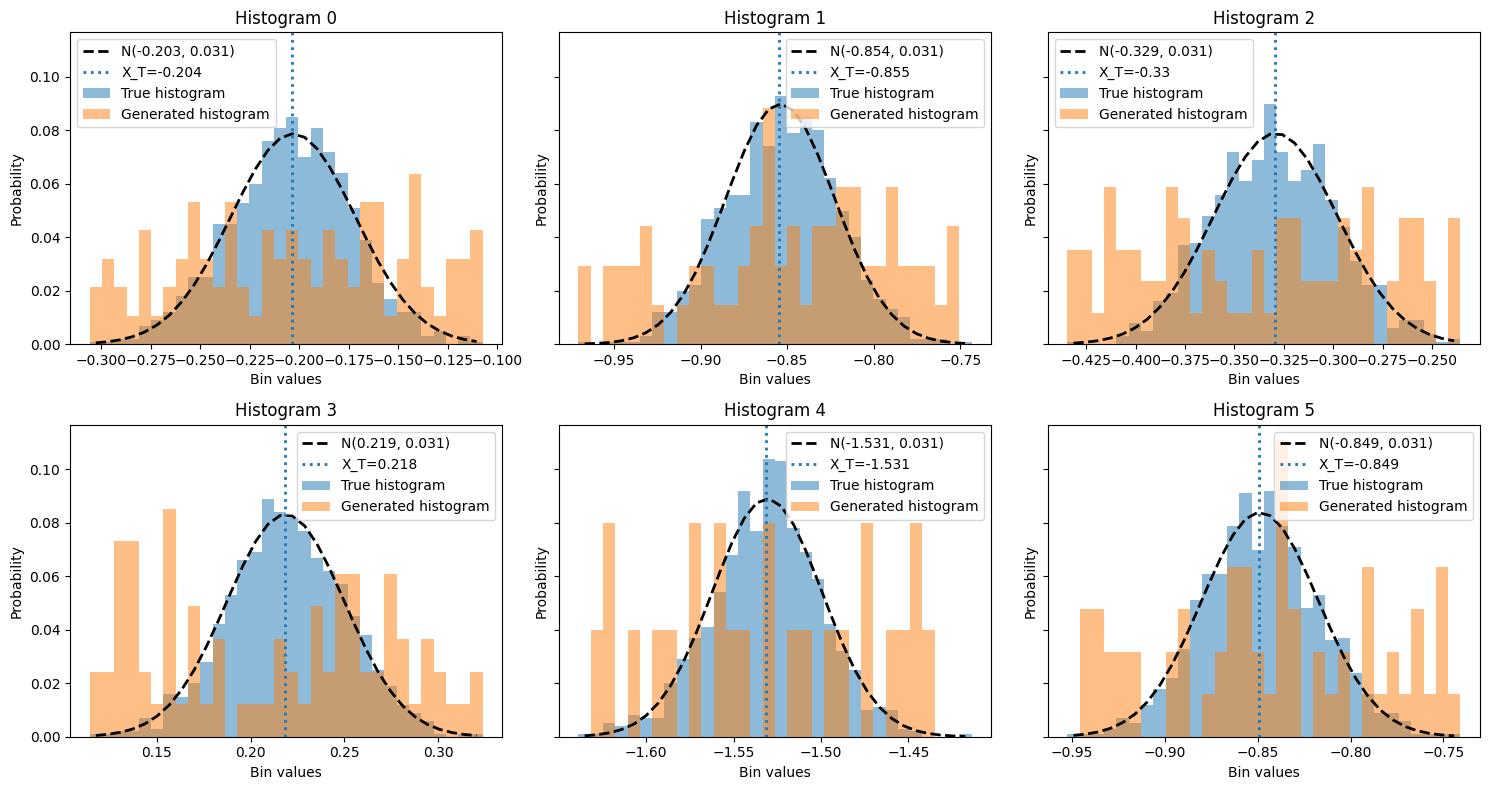

In [3]:
means = sim.means
stds = sim.stds
plot_bin_dist(true_pdfs, generated_pdfs,
            bins_values=bin_edges_list,
            X_T=paths[:, -1],
            stds=stds,
            means=means,
            zoom=False)